In [1]:
from pyspark.sql import SparkSession

In [2]:
spark = (SparkSession.builder
  .appName("Reconnaissance")
  .master("spark://spark-master:7077")
  # le driver écoute sur toutes les interfaces du conteneur: évite les problème de binding réseau
  .config("spark.driver.bindAddress", "0.0.0.0")
  # et se présente aux workers avec un nom atteignable sur le réseau docker
  .config("spark.driver.host", "spark-jupyter")  # ou l’IP retournée par `hostname -i` dans le conteneur
  .getOrCreate())

In [3]:
for item in spark.sparkContext.getConf().getAll():
    print(item)

('spark.files', 'file:///home/spark/.ivy2/jars/org.apache.spark_spark-sql-kafka-0-10_2.12-3.5.0.jar,file:///home/spark/.ivy2/jars/org.apache.kafka_kafka-clients-3.8.0.jar,file:///home/spark/.ivy2/jars/org.apache.spark_spark-token-provider-kafka-0-10_2.12-3.5.0.jar,file:///home/spark/.ivy2/jars/com.google.code.findbugs_jsr305-3.0.0.jar,file:///home/spark/.ivy2/jars/org.apache.commons_commons-pool2-2.11.1.jar,file:///home/spark/.ivy2/jars/org.apache.hadoop_hadoop-client-runtime-3.3.4.jar,file:///home/spark/.ivy2/jars/org.apache.hadoop_hadoop-client-api-3.3.4.jar,file:///home/spark/.ivy2/jars/org.slf4j_slf4j-api-2.0.7.jar,file:///home/spark/.ivy2/jars/commons-logging_commons-logging-1.1.3.jar,file:///home/spark/.ivy2/jars/com.github.luben_zstd-jni-1.5.6-3.jar,file:///home/spark/.ivy2/jars/org.lz4_lz4-java-1.8.0.jar,file:///home/spark/.ivy2/jars/org.xerial.snappy_snappy-java-1.1.10.5.jar')
('spark.driver.port', '43617')
('spark.app.startTime', '1765272407759')
('spark.app.initial.jar.urls'

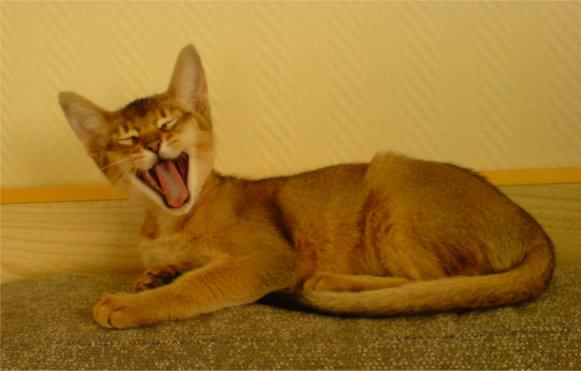

In [4]:
from IPython.display import Image, display
display(Image(filename='./source/images/cat/Abyssinian_155_jpg.rf.fdd90a163673ab77ec9690317a69b94e.jpg'))

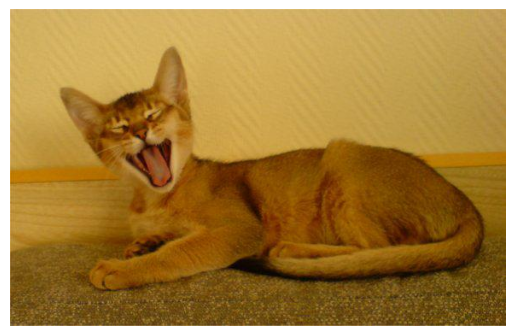

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('./source/images/cat/Abyssinian_155_jpg.rf.fdd90a163673ab77ec9690317a69b94e.jpg')
plt.imshow(img)
plt.axis('off')   # masque les axes
plt.show()


In [ ]:
from pyspark.sql.functions import col, regexp_extract, when

# 1) Lecture des images
images_df = (
    spark.read
         .format("image")              # data source "image" de Spark
         .option("dropInvalid", True)
         .load("./source/images/*/*")   # sous-dossiers cats/ et dogs/
)

images_df.printSchema()
images_df.select("image.origin", "image.width", "image.height").show(5, truncate=False)
